In [43]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.metrics import classification_report, accuracy_score
import umap
import random
%matplotlib inline

### SDSS

In [44]:
sdss_preds_reg = np.load("preds_reg.npy")
sdss_preds_cls = np.load("preds_cls.npy")

sdss_true_reg = np.load("true_reg.npy")
sdss_true_cls = np.load("true_cls.npy")

sdss_recon_spectra = np.load("sdss_reconstructed_spectra.npy")
sdss_latent_var = np.load("sdss_latent_mu.npy")

In [45]:
sdss_mae_teff = np.mean(np.abs(sdss_preds_reg[:, 0] - sdss_true_reg[:, 0]))
sdss_mae_logg = np.mean(np.abs(sdss_preds_reg[:, 1] - sdss_true_reg[:, 1]))
sdss_mae_feh  = np.mean(np.abs(sdss_preds_reg[:, 2] - sdss_true_reg[:, 2]))

#### SDSS Classification Accuracy

In [46]:
print(classification_report(sdss_preds_cls, sdss_true_cls))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       138
           1       0.81      0.84      0.83       140
           2       0.88      0.94      0.91       584
           3       0.87      0.85      0.86       616
           4       0.94      0.91      0.92       651
           5       0.97      0.96      0.96       575
           6       0.98      0.99      0.99       538

    accuracy                           0.92      3242
   macro avg       0.92      0.91      0.91      3242
weighted avg       0.92      0.92      0.92      3242



#### SDSS Atmospheric parameters estimation

In [47]:
reg_sigma = np.load("../../models/reg_sigma.npy")
reg_mu = np.load("../../models/reg_mu.npy")

In [48]:
sdss_mae_teff_physical = sdss_mae_teff * reg_sigma[0]  # Kelvin
sdss_mae_logg_physical = sdss_mae_logg * reg_sigma[1]  # dex
sdss_mae_feh_physical  = sdss_mae_feh  * reg_sigma[2]  # dex

print(f"MAE Teff:   {sdss_mae_teff_physical:.2f} K")
print(f"MAE logg:   {sdss_mae_logg_physical:.4f} dex")
print(f"MAE [Fe/H]: {sdss_mae_feh_physical:.4f} dex")

MAE Teff:   384.50 K
MAE logg:   0.3337 dex
MAE [Fe/H]: 0.3323 dex


In [49]:
sdss_flux = np.load("sdss_flux.npy")

#### SDSS Reconstruction

In [50]:
sdss_mae_recon = np.mean(np.abs(sdss_flux - sdss_recon_spectra))
print(sdss_mae_recon)

0.17513876


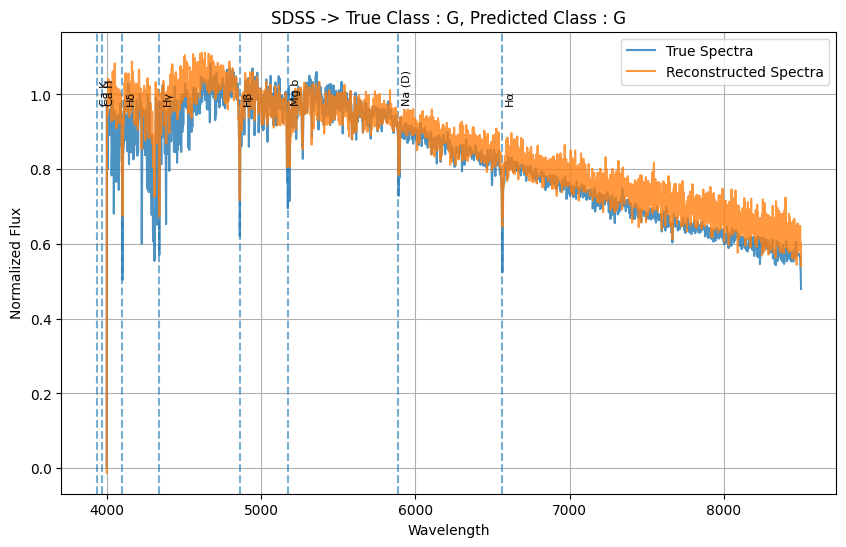

In [51]:
LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

wavelength_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)
random_star_index_sdss = random.randint(0, 3241)
sdss_star_flux = sdss_flux[random_star_index_sdss]
sdss_recon_flux = sdss_recon_spectra[random_star_index_sdss]

sdss_true_class = ""
sdss_pred_class = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == sdss_true_cls[random_star_index_sdss]:
        sdss_true_class = i
    if spectral_class_dict[i] == sdss_preds_cls[random_star_index_sdss]:
        sdss_pred_class = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"SDSS -> True Class : {sdss_true_class}, Predicted Class : {sdss_pred_class}")
plt.grid()
plt.plot(wavelength_grid, sdss_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, sdss_recon_flux, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

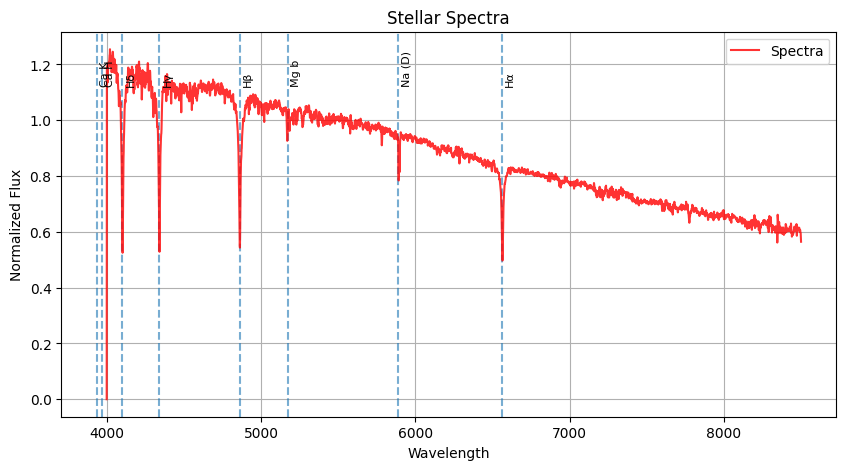

In [52]:
LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

wavelength_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)
random_star_index_sdss = random.randint(0, 3241)
sdss_star_flux = sdss_flux[random_star_index_sdss]
sdss_recon_flux = sdss_recon_spectra[random_star_index_sdss]

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize= (10, 5))
# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"Stellar Spectra")
plt.grid()
plt.plot(wavelength_grid, sdss_star_flux, label = "Spectra", alpha = 0.8, color = "r")
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

In [53]:
for i in spectral_class_dict:
    print(i)

O
B
A
F
G
K
M


### LAMOST (Model Transfer)

In [54]:
lamost_preds_reg = np.load("lamost_preds_reg.npy")
lamost_preds_cls = np.load("lamost_preds_cls.npy")

lamost_true_reg = np.load("lamost_true_reg.npy")
lamost_true_cls = np.load("lamost_true_cls.npy")

lamost_recon_spectra = np.load("lamost_reconstructed_spectra.npy")
lamost_flux = np.load("lamost_flux.npy")

In [55]:
lamost_mae_teff = np.mean(np.abs(lamost_preds_reg[:, 0] - lamost_true_reg[:, 0]))
lamost_mae_logg = np.mean(np.abs(lamost_preds_reg[:, 1] - lamost_true_reg[:, 1]))
lamost_mae_feh  = np.mean(np.abs(lamost_preds_reg[:, 2] - lamost_true_reg[:, 2]))

#### LAMOST classification accuracy

In [56]:
print(classification_report(lamost_preds_cls,lamost_true_cls))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00        38
           2       0.84      0.81      0.82      1094
           3       0.63      0.68      0.65      4730
           4       0.64      0.76      0.69      7530
           5       0.96      0.70      0.81      6373
           6       0.00      0.00      0.00        26

    accuracy                           0.72     19800
   macro avg       0.44      0.42      0.43     19800
weighted avg       0.75      0.72      0.73     19800



/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

#### LAMOST Atmospheric parameters estimation

In [15]:
lamost_mae_teff_physical = lamost_mae_teff * reg_sigma[0]  # Kelvin
lamost_mae_logg_physical = lamost_mae_logg * reg_sigma[1]  # dex
lamost_mae_feh_physical  = lamost_mae_feh  * reg_sigma[2]  # dex

print(f"MAE Teff:   {lamost_mae_teff_physical:.2f} K")
print(f"MAE logg:   {lamost_mae_logg_physical:.4f} dex")
print(f"MAE [Fe/H]: {lamost_mae_feh_physical:.4f} dex")

MAE Teff:   669.54 K
MAE logg:   0.7740 dex
MAE [Fe/H]: 0.6661 dex


#### LAMOST Reconstruction

In [16]:
lamost_mae_recon = np.mean(np.abs(lamost_flux - lamost_recon_spectra))
# print(lamost_recon_spectra.shape)
print(lamost_mae_recon)

0.15410239


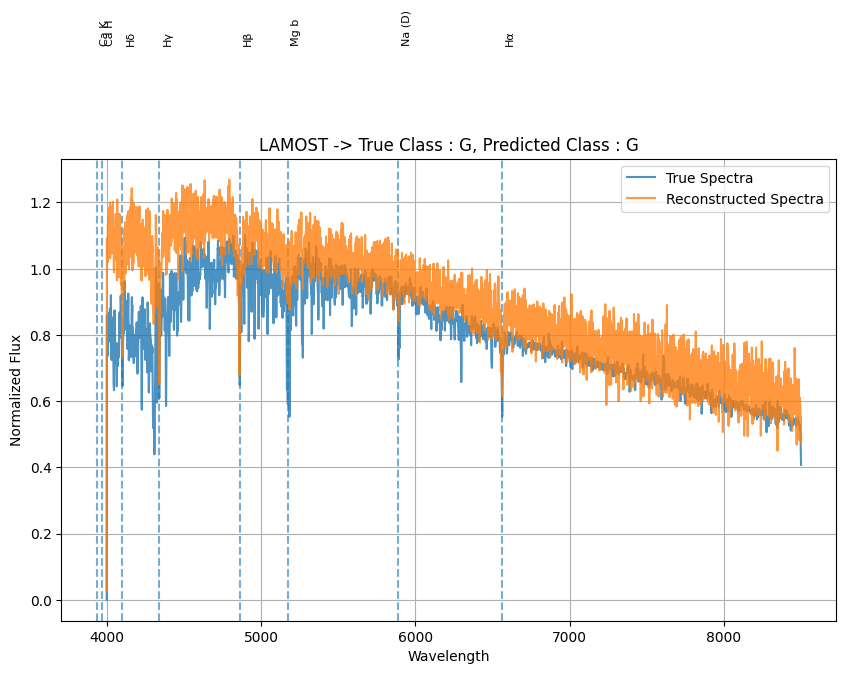

In [17]:
random_star_index_lamost = random.randint(0, 19799)
lamost_star_flux = lamost_flux[random_star_index_lamost]
lamost_star_recon = lamost_recon_spectra[random_star_index_lamost]

lamost_true_class = ""
lamost_pred_class = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == lamost_true_cls[random_star_index_sdss]:
        lamost_true_class = i
    if spectral_class_dict[i] == lamost_preds_cls[random_star_index_sdss]:
        lamost_pred_class = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"LAMOST -> True Class : {lamost_true_class}, Predicted Class : {lamost_pred_class}")
plt.grid()
plt.plot(wavelength_grid, lamost_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, lamost_star_recon, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

In [18]:
import h5py

In [19]:
sdss_data = h5py.File("/home/arbiter/projects/Survey-invariant-generalization/data/usable_data/sdss_resampled.h5")

#### Latent Space Visualization

In [20]:
sdss_latent_vec = np.load("sdss_latent_mu.npy")
lamost_latent_vec = np.load("lamost_latent_mu.npy")

In [21]:
reducer = umap.UMAP(n_components=2, random_state= 42, n_neighbors= 30)

In [22]:
sdss_latent_vec.shape

(3242, 128)

In [23]:
sdss_2d = reducer.fit_transform(sdss_latent_vec)
lamost_2d = reducer.fit_transform(lamost_latent_vec)

/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [24]:
sdss_teff = sdss_true_reg[:, 0]
lamost_teff = lamost_true_reg[:, 0]

sdss_logg = sdss_true_reg[:, 1]
lamost_logg = lamost_true_reg[:, 1]

sdss_metallicity = sdss_true_reg[:, 2]
lamost_metallicity = lamost_true_reg[:, 2]

# denormalizing the labels
sdss_teff_k = sdss_teff * reg_sigma[0] + reg_mu[0]
lamost_teff_k = lamost_teff * reg_sigma[0] + reg_mu[0]

sdss_logg_dex = sdss_logg * reg_sigma[1] + reg_mu[1]
lamost_logg_dex = lamost_logg * reg_sigma[1] + reg_mu[1]

sdss_metallicity_dex = sdss_metallicity * reg_sigma[2] + reg_mu[2]
lamost_metallicity_dex = lamost_metallicity * reg_sigma[2] + reg_mu[2]

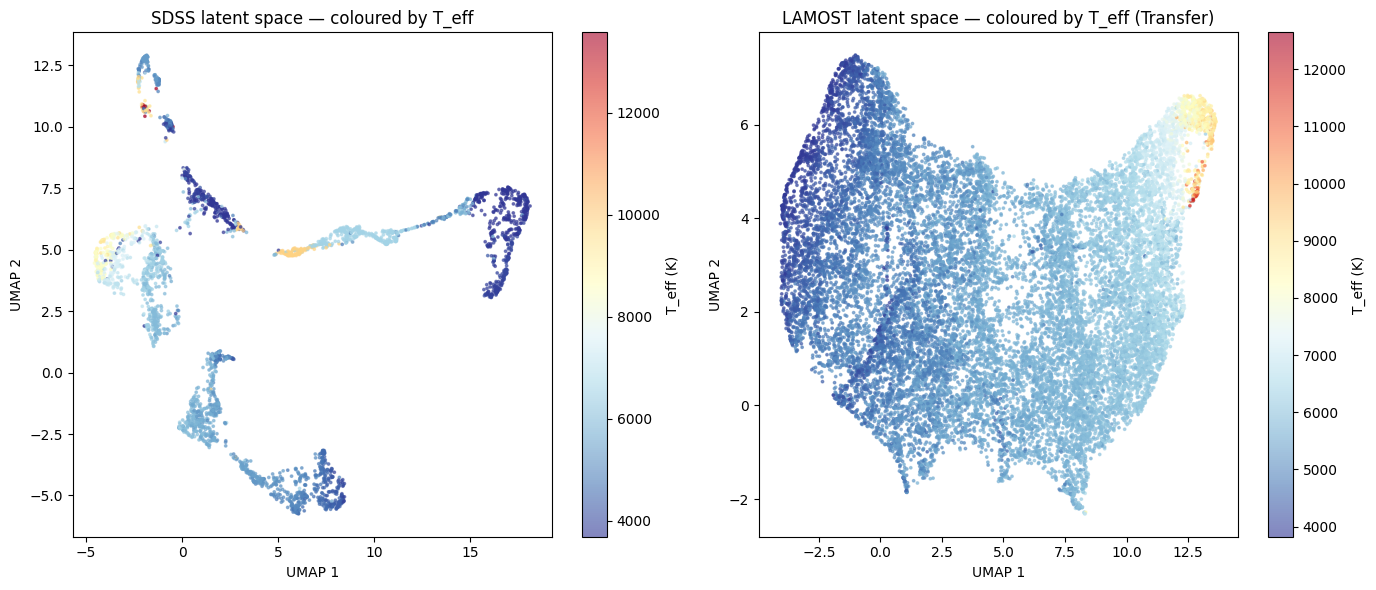

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SDSS colored by Teff
sc1 = axes[0].scatter(sdss_2d[:, 0], sdss_2d[:, 1],
                       c=sdss_teff_k, cmap='RdYlBu_r', s=3, alpha=0.6)
plt.colorbar(sc1, ax=axes[0], label='T_eff (K)')
axes[0].set_title('SDSS latent space — coloured by T_eff')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# LAMOST colored by Teff
sc2 = axes[1].scatter(lamost_2d[:, 0], lamost_2d[:, 1],
                       c=lamost_teff_k, cmap='RdYlBu_r', s=3, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='T_eff (K)')
axes[1].set_title('LAMOST latent space — coloured by T_eff (Transfer)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('umap_latent_teff.png', dpi=150, bbox_inches='tight')
plt.show()


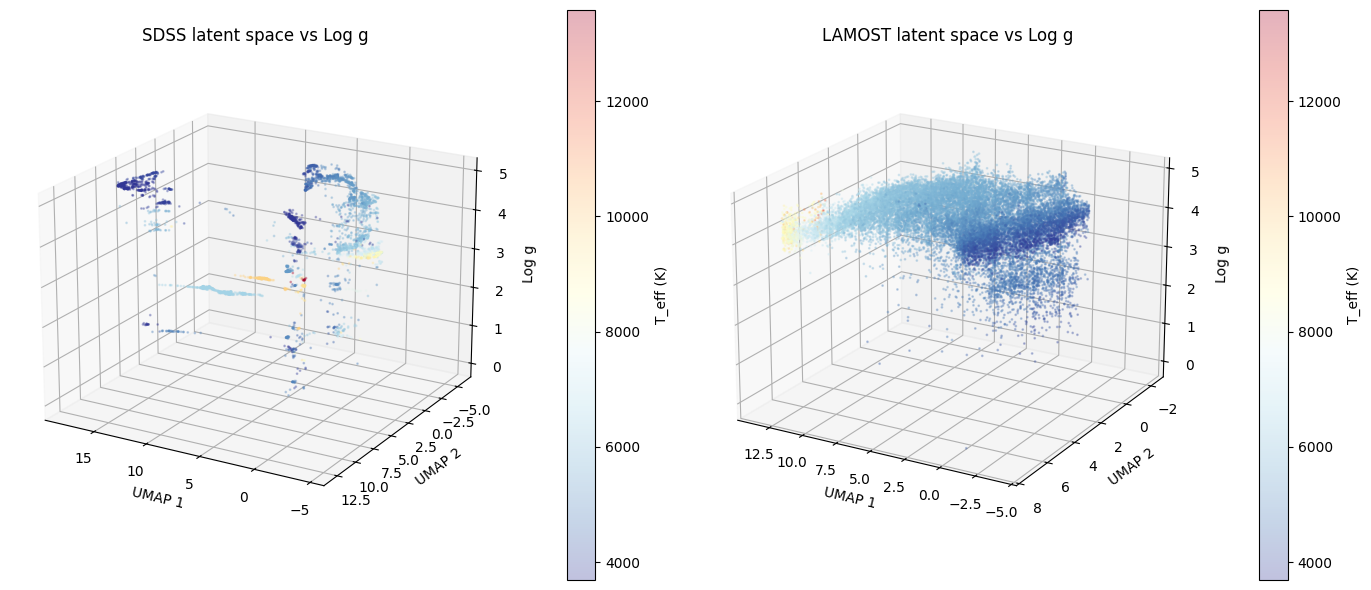

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Subsample (VERY IMPORTANT) ----
N = 20000  # adjust depending on density
sdss_idx = np.random.choice(len(sdss_2d), min(N, len(sdss_2d)), replace=False)
lamost_idx = np.random.choice(len(lamost_2d), min(N, len(lamost_2d)), replace=False)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Shared color scale (important for comparison)
vmin = min(sdss_teff_k.min(), lamost_teff_k.min())
vmax = max(sdss_teff_k.max(), lamost_teff_k.max())

# ---- SDSS ----
sc1 = ax1.scatter(
    sdss_2d[sdss_idx, 0],
    sdss_2d[sdss_idx, 1],
    sdss_logg_dex[sdss_idx],
    c=sdss_teff_k[sdss_idx],
    cmap='RdYlBu_r',
    s=1,
    alpha=0.3,
    vmin=vmin, vmax=vmax,
    depthshade=False,
    rasterized=True
)

ax1.view_init(elev=20, azim=120)

ax1.set_title('SDSS latent space vs Log g')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_zlabel('Log g')

cbar1 = plt.colorbar(sc1, ax=ax1, pad=0.1)
cbar1.set_label('T_eff (K)')

# ---- LAMOST ----
sc2 = ax2.scatter(
    lamost_2d[lamost_idx, 0],
    lamost_2d[lamost_idx, 1],
    lamost_logg_dex[lamost_idx],
    c=lamost_teff_k[lamost_idx],
    cmap='RdYlBu_r',
    s=1,
    alpha=0.3,
    vmin=vmin, vmax=vmax,
    depthshade=False,
    rasterized=True
)

ax2.view_init(elev=20, azim=120)

ax2.set_title('LAMOST latent space vs Log g')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('Log g')

cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.1)
cbar2.set_label('T_eff (K)')

plt.tight_layout()
plt.savefig('clean_umap_latent_teff.png', dpi=200, bbox_inches='tight')
plt.show()

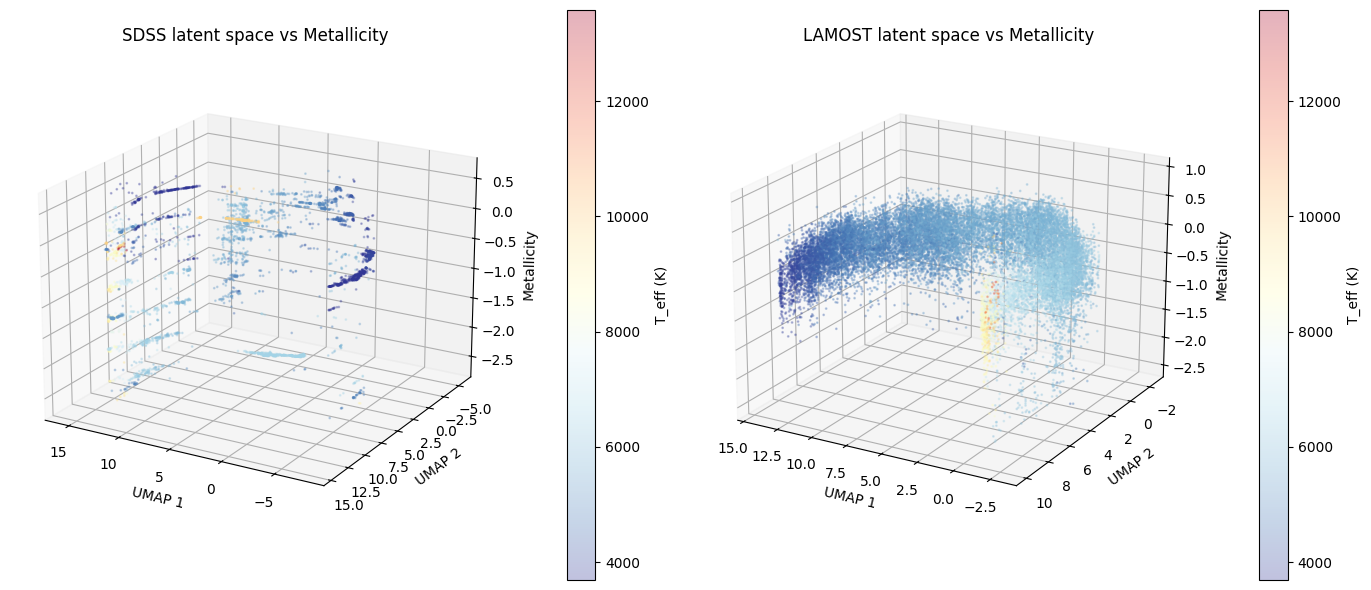

In [28]:
N = 20000  # adjust depending on density
sdss_idx = np.random.choice(len(sdss_2d), min(N, len(sdss_2d)), replace=False)
lamost_idx = np.random.choice(len(lamost_2d), min(N, len(lamost_2d)), replace=False)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Shared color scale (important for comparison)
vmin = min(sdss_teff_k.min(), lamost_teff_k.min())
vmax = max(sdss_teff_k.max(), lamost_teff_k.max())

# ---- SDSS ----
sc1 = ax1.scatter(
    sdss_2d[sdss_idx, 0],
    sdss_2d[sdss_idx, 1],
    sdss_metallicity_dex[sdss_idx],
    c=sdss_teff_k[sdss_idx],
    cmap='RdYlBu_r',
    s=1,
    alpha=0.3,
    vmin=vmin, vmax=vmax,
    depthshade=False,
    rasterized=True
)

ax1.view_init(elev=20, azim=120)

ax1.set_title('SDSS latent space vs Metallicity')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_zlabel('Metallicity')

cbar1 = plt.colorbar(sc1, ax=ax1, pad=0.1)
cbar1.set_label('T_eff (K)')

# ---- LAMOST ----
sc2 = ax2.scatter(
    lamost_2d[lamost_idx, 0],
    lamost_2d[lamost_idx, 1],
    lamost_metallicity_dex[lamost_idx],
    c=lamost_teff_k[lamost_idx],
    cmap='RdYlBu_r',
    s=1,
    alpha=0.3,
    vmin=vmin, vmax=vmax,
    depthshade=False,
    rasterized=True
)

ax2.view_init(elev=20, azim=120)

ax2.set_title('LAMOST latent space vs Metallicity')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('Metallicity')

cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.1)
cbar2.set_label('T_eff (K)')

plt.tight_layout()
plt.savefig('clean_umap_latent_teff.png', dpi=200, bbox_inches='tight')
plt.show()

Checking classification accuracy in LAMOST for available classes

In [30]:
lamost_true_cls

array([4, 3, 3, ..., 3, 3, 3], shape=(19800,))

### Latent Space distribution Overlapping

#### Kolmogorov-Smirnov Test: 

In [2]:
from scipy.stats import ks_2samp

In [28]:
print(lamost_latent_vec.shape)
print(sdss_latent_vec.shape)

(19800, 128)
(3242, 128)


In [36]:
sdss_latent_vec

array([[ 0.53861254,  0.14823224, -0.7915404 , ..., -0.15589207,
         0.30627483, -0.11591396],
       [-0.37286836, -0.03248662, -0.1299498 , ...,  0.10124607,
        -0.20135486, -0.01098653],
       [-0.06686225,  0.06884986, -0.03308978, ...,  0.04924171,
        -0.17566133, -0.00834824],
       ...,
       [ 0.26411062,  0.20622267, -0.05248141, ...,  0.10160165,
         0.1352377 , -0.2692734 ],
       [ 0.05784446,  0.12618588,  0.1065483 , ..., -0.08476907,
        -0.03949578,  0.0928122 ],
       [ 0.04605481,  0.15798266, -0.06756545, ..., -0.00698926,
        -0.03277006,  0.00110638]], shape=(3242, 128), dtype=float32)

In [46]:
ks_stat_list = []
ks_pval_list = []

for dim in range(sdss_latent_vec.shape[1]):
    stat, pval = ks_2samp(data1= sdss_latent_vec[:, dim], data2=lamost_latent_vec[:, dim])
    
    ks_stat_list.append(stat)
    ks_pval_list.append(pval)

ks_stats = np.array(ks_stat_list)
ks_pvals = np.array(ks_pval_list)

print(f"Mean KS statistic:              {ks_stats.mean():.4f}")
print(f"Median KS statistic:            {np.median(ks_stats):.4f}")
print(f"Dims with KS stat < 0.1:        {(ks_stats < 0.1).sum()}/128")

print((ks_pvals > 0.05).sum())       # fail to reject null hypothesis
print((ks_pvals < 0.05).sum())       # reject null hypothesis

Mean KS statistic:              0.2220
Median KS statistic:            0.2149
Dims with KS stat < 0.1:        9/128
0
128


### Correlation

In [49]:
from scipy.stats import spearmanr
import numpy as np

sdss_mu   = np.load("sdss_latent_mu.npy")
sdss_true = np.load("true_reg.npy")
reg_sigma = np.load("../../models/reg_sigma.npy")
reg_mu = np.load("../../models/reg_mu.npy")

teff = sdss_true[:, 0] * reg_sigma[0] + reg_mu[0]
logg = sdss_true[:, 1] * reg_sigma[1] + reg_mu[1]
feh  = sdss_true[:, 2] * reg_sigma[2] + reg_mu[2]

params = {"T_eff": teff, "log_g": logg, "Fe_H": feh}

for param_name, param_vals in params.items():
    rhos, pvals = [], []
    
    for dim in range(sdss_mu.shape[1]):
        rho, p = spearmanr(sdss_mu[:, dim], param_vals)
        rhos.append(rho)
        pvals.append(p)
    
    rhos  = np.array(rhos)
    pvals = np.array(pvals)
    
    
    print(f"\n=== H2: Spearman Correlation — {param_name} ===")
    print(f"H0: rho = 0 for all latent dims")
    print(f"H1: at least some dims have rho != 0")
    print(f"")
    print(f"Uncorrected  (p<0.05): {(pvals < 0.05).sum():>4}/128 significant dims")
    print(f"")
    print(f"Max |rho|:   {np.max(np.abs(rhos)):.4f}  (dim {np.argmax(np.abs(rhos))})")


=== H2: Spearman Correlation — T_eff ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  116/128 significant dims

Max |rho|:   0.7106  (dim 123)

=== H2: Spearman Correlation — log_g ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  110/128 significant dims

Max |rho|:   0.5501  (dim 123)

=== H2: Spearman Correlation — Fe_H ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  110/128 significant dims

Max |rho|:   0.4383  (dim 121)


In [51]:
from scipy.stats import spearmanr
import numpy as np

lamost_mu   = np.load("lamost_latent_mu.npy")
lamost_true = np.load("lamost_true_reg.npy")
reg_sigma = np.load("../../models/reg_sigma.npy")
reg_mu = np.load("../../models/reg_mu.npy")

teff = lamost_true[:, 0] * reg_sigma[0] + reg_mu[0]
logg = lamost_true[:, 1] * reg_sigma[1] + reg_mu[1]
feh  = lamost_true[:, 2] * reg_sigma[2] + reg_mu[2]

params = {"T_eff": teff, "log_g": logg, "Fe_H": feh}

for param_name, param_vals in params.items():
    rhos, pvals = [], []
    
    for dim in range(lamost_mu.shape[1]):
        rho, p = spearmanr(lamost_mu[:, dim], param_vals)
        rhos.append(rho)
        pvals.append(p)
    
    rhos  = np.array(rhos)
    pvals = np.array(pvals)
    
    
    print(f"\n=== H2: Spearman Correlation — {param_name} ===")
    print(f"H0: rho = 0 for all latent dims")
    print(f"H1: at least some dims have rho != 0")
    print(f"")
    print(f"Uncorrected  (p<0.05): {(pvals < 0.05).sum():>4}/128 significant dims")
    print(f"")
    print(f"Max |rho|:   {np.max(np.abs(rhos)):.4f}  (dim {np.argmax(np.abs(rhos))})")


=== H2: Spearman Correlation — T_eff ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  128/128 significant dims

Max |rho|:   0.9325  (dim 12)

=== H2: Spearman Correlation — log_g ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  125/128 significant dims

Max |rho|:   0.4211  (dim 66)

=== H2: Spearman Correlation — Fe_H ===
H0: rho = 0 for all latent dims
H1: at least some dims have rho != 0

Uncorrected  (p<0.05):  120/128 significant dims

Max |rho|:   0.3799  (dim 30)
